# Sesión 5 monitoría

In [2]:
import requests
import pandas as pd
import wikipedia
import matplotlib.pyplot as plt
from sodapy import Socrata
from openai import OpenAI
from IPython.display import display, Image

## Obtener datos de APIs abiertas

### Datos de la bolsa: alphavantage

In [ ]:
url = "https://www.alphavantage.co/query"
params = {
    "function": "TIME_SERIES_DAILY",
    "symbol": "AAPL",
    "apikey": "", #<- Poner API Key
    "outputsize": "compact"
}

r = requests.get(url, params=params).json()

In [4]:
df = pd.DataFrame(r["Time Series (Daily)"]).T
df.columns = ["open", "high", "low", "close", "volume"]
df.index = pd.to_datetime(df.index)
df

,open,high,low,close,volume
2026-03-03,263.4800,265.5600,260.1300,263.7500,38020971
2026-03-02,262.4100,266.5300,260.2000,264.7200,41827946
2026-02-27,272.8100,272.8100,262.8900,264.1800,72366505
2026-02-26,274.9450,276.1100,270.7950,272.9500,32345114
2026-02-25,271.7800,274.9400,271.0500,274.2300,33714342
...,...,...,...,...,...
2025-10-14,246.6000,248.8450,244.7000,247.7700,35477986
2025-10-13,249.3800,249.6900,245.5600,247.6600,38142942
2025-10-10,254.9400,256.3800,244.0000,245.2700,61999098
2025-10-09,257.8050,258.0000,253.1400,254.0400,38322012


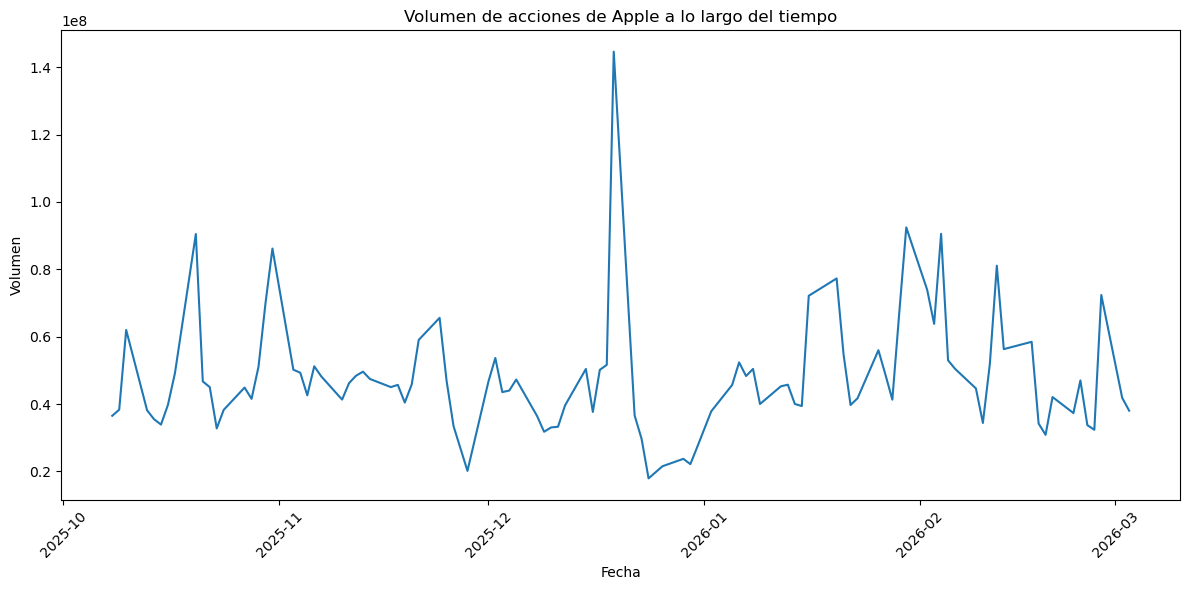

In [5]:
df.index = pd.to_datetime(df.index)

# Convertir columnas numéricas
df = df.astype(float)

# Graficar
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['volume'])
plt.xlabel('Fecha')
plt.ylabel('Volumen')
plt.title(f'Volumen de acciones de Apple a lo largo del tiempo')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### Datos abiertos Colombia

In [6]:
# Unauthenticated client only works with public data sets. Note 'None'
# in place of application token, and no username or password:
client = Socrata("www.datos.gov.co", None)

# Example authenticated client (needed for non-public datasets):
# client = Socrata(www.datos.gov.co,
#                  MyAppToken,
#                  username="user@example.com",
#                  password="AFakePassword")

# First 2000 results, returned as JSON from API / converted to Python list of
# dictionaries by sodapy.
results = client.get("ceyp-9c7c", limit=8222)

# Convert to pandas DataFrame
results_df = pd.DataFrame.from_records(results)

In [7]:
results_df

,valor,vigenciadesde,vigenciahasta
0,643.42,1991-12-02T00:00:00.000,1991-12-02T00:00:00.000
1,639.22,1991-12-03T00:00:00.000,1991-12-03T00:00:00.000
2,635.7,1991-12-04T00:00:00.000,1991-12-04T00:00:00.000
3,631.51,1991-12-05T00:00:00.000,1991-12-05T00:00:00.000
4,627.16,1991-12-06T00:00:00.000,1991-12-06T00:00:00.000
...,...,...,...
8217,3703.69,2026-02-26T00:00:00.000,2026-02-26T00:00:00.000
8218,3745.78,2026-02-27T00:00:00.000,2026-02-27T00:00:00.000
8219,3766.3,2026-02-28T00:00:00.000,2026-03-02T00:00:00.000
8220,3768.73,2026-03-03T00:00:00.000,2026-03-03T00:00:00.000


In [9]:
results_df['vigenciadesde']=pd.to_datetime(results_df['vigenciadesde'])
results_df['vigenciahasta']=pd.to_datetime(results_df['vigenciahasta'])
results_df['valor'] = results_df['valor'].astype(float)
results_df

,valor,vigenciadesde,vigenciahasta
0,643.42,1991-12-02,1991-12-02
1,639.22,1991-12-03,1991-12-03
2,635.70,1991-12-04,1991-12-04
3,631.51,1991-12-05,1991-12-05
4,627.16,1991-12-06,1991-12-06
...,...,...,...
8217,3703.69,2026-02-26,2026-02-26
8218,3745.78,2026-02-27,2026-02-27
8219,3766.30,2026-02-28,2026-03-02
8220,3768.73,2026-03-03,2026-03-03


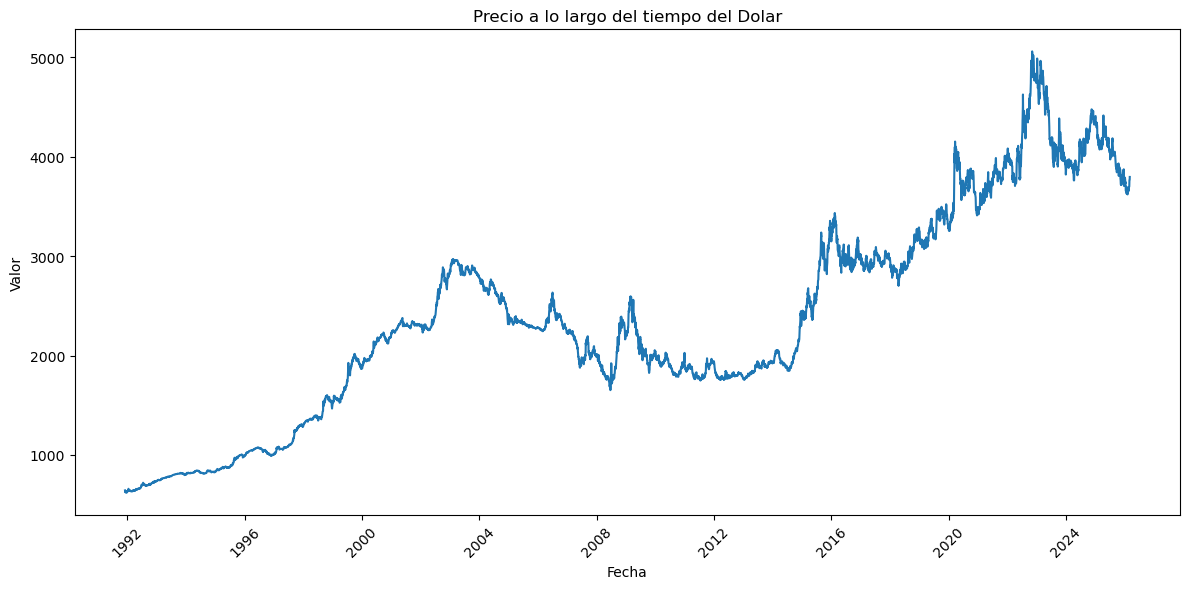

In [10]:
# Graficar
plt.figure(figsize=(12, 6))
plt.plot(results_df['vigenciadesde'], results_df['valor'])
plt.xlabel('Fecha')
plt.ylabel('Valor')
plt.title(f'Precio a lo largo del tiempo del Dolar')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### Datos meteorológicos

In [11]:
# Coordenadas de Bogotá, Colombia
lat = 4.7110
lon = -74.0721

# API Open-Meteo
url = f"https://api.open-meteo.com/v1/forecast?latitude={lat}&longitude={lon}&hourly=precipitation"

data = requests.get(url).json()
data

{'latitude': 4.75,
 'longitude': -74.125,
 'generationtime_ms': 0.026106834411621094,
 'utc_offset_seconds': 0,
 'timezone': 'GMT',
 'timezone_abbreviation': 'GMT',
 'elevation': 2557.0,
 'hourly_units': {'time': 'iso8601', 'precipitation': 'mm'},
 'hourly': {'time': ['2026-03-04T00:00',
   '2026-03-04T01:00',
   '2026-03-04T02:00',
   '2026-03-04T03:00',
   '2026-03-04T04:00',
   '2026-03-04T05:00',
   '2026-03-04T06:00',
   '2026-03-04T07:00',
   '2026-03-04T08:00',
   '2026-03-04T09:00',
   '2026-03-04T10:00',
   '2026-03-04T11:00',
   '2026-03-04T12:00',
   '2026-03-04T13:00',
   '2026-03-04T14:00',
   '2026-03-04T15:00',
   '2026-03-04T16:00',
   '2026-03-04T17:00',
   '2026-03-04T18:00',
   '2026-03-04T19:00',
   '2026-03-04T20:00',
   '2026-03-04T21:00',
   '2026-03-04T22:00',
   '2026-03-04T23:00',
   '2026-03-05T00:00',
   '2026-03-05T01:00',
   '2026-03-05T02:00',
   '2026-03-05T03:00',
   '2026-03-05T04:00',
   '2026-03-05T05:00',
   '2026-03-05T06:00',
   '2026-03-05T07:00'

In [15]:
# Crear DataFrame con las variables horarias
df = pd.DataFrame({
    "time": data["hourly"]["time"],
    "precipitation": data["hourly"]["precipitation"]
})

df['time']=pd.to_datetime(df['time']).dt.date
df

,time,precipitation
0,2026-03-04,0.0
1,2026-03-04,0.0
2,2026-03-04,0.0
3,2026-03-04,0.0
4,2026-03-04,0.0
...,...,...
163,2026-03-10,2.1
164,2026-03-10,2.1
165,2026-03-10,2.1
166,2026-03-10,0.6


In [16]:
df_agregado=df.groupby('time').agg({'precipitation': 'sum'})
df_agregado

,precipitation
time,
2026-03-04,0.5
2026-03-05,2.1
2026-03-06,6.9
2026-03-07,5.6
2026-03-08,6.6
2026-03-09,6.5
2026-03-10,13.2


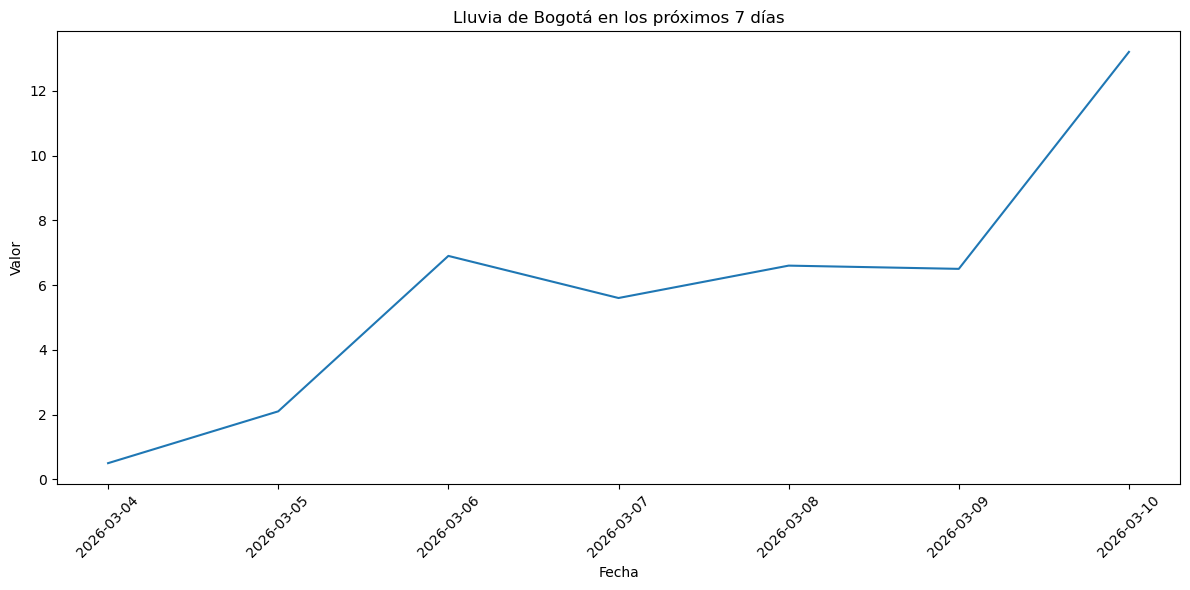

In [19]:
# Graficar
plt.figure(figsize=(12, 6))
plt.plot(df_agregado.index, df_agregado['precipitation'])
plt.xlabel('Fecha')
plt.ylabel('Valor')
plt.title(f'Lluvia de Bogotá en los próximos 7 días')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Wikipedia

In [24]:
# 1. Configurar el idioma de búsqueda (es = español, en = inglés)
wikipedia.set_lang("es")

# 2. Definir el término de búsqueda
termino = "Python"

try:
    # Buscar el artículo exacto
    pagina = wikipedia.page(termino)

    print(f"Título del Artículo: {pagina.title}")
    print(f"URL: {pagina.url}\n")

    # 3. Extraer el resumen (ideal para generar metadatos o embeddings rápidos)
    print("Resumen:")
    print(pagina.summary[:1000] + "...\n") # Mostramos solo los primeros 500 caracteres

except wikipedia.exceptions.DisambiguationError as e:
    print(f"El término es ambiguo. Opciones posibles: {e.options}")
except wikipedia.exceptions.PageError:
    print("La página no fue encontrada.")

Título del Artículo: Python
URL: https://es.wikipedia.org/wiki/Python

Resumen:
Python es un lenguaje de alto nivel de programación interpretado cuya filosofía hace hincapié en la legibilidad de su código. Se trata de un lenguaje de programación multiparadigma, ya que soporta parcialmente la orientación a objetos, programación imperativa y, en menor medida, programación funcional. Es un lenguaje interpretado, dinámico, multiplataforma.
Administrado por Python Software Foundation, posee una licencia de código abierto, denominada Python Software Foundation License.​ Python se clasifica constantemente como uno de los lenguajes de programación más populares, siendo ya en 2025 el más popular y además con una amplia diferencia récord histórico de más de 15 puntos porcentuales sobre el siguiente.​

...



## Interactuar con ChatGPT desde Python

In [ ]:
chat_gpt_key=''

In [29]:
# Inicializa el cliente
client = OpenAI(api_key=chat_gpt_key)

prompt = "¿En qué equipo juega Cristiano Ronaldo?"

# Llamada al modelo
response = client.chat.completions.create(
    model="gpt-5",
    messages=[{"role": "user", "content": prompt}],
    temperature=1
)

# Extraer contenido
mensaje = response.choices[0].message.content
print(mensaje)

Cristiano Ronaldo juega en Al Nassr (Arabia Saudí), en la Saudi Pro League. Además, es internacional con la selección de Portugal.


In [30]:
# El prompt ahora debe ser una descripción visual
prompt = "Una imagen de un gato jugando baloncesto"

# Llamada al modelo de generación de imágenes
response = client.images.generate(
    model="dall-e-3",
    prompt=prompt,
    n=1,
    size="1024x1024" # Tamaño de la imagen
)

# Extraer y mostrar la URL de la imagen generada
image_url = response.data[0].url

# Imprimir la URL por si acaso la necesitas
print("Generación exitosa. Mostrando imagen...")

# Mostrar la imagen directamente en el Notebook
display(Image(url=image_url))

Generación exitosa. Mostrando imagen...


In [42]:
image_url

'https://oaidalleapiprodscus.blob.core.windows.net/private/org-S5JoGklpHwlkABYFslGCnnsc/user-EQaPeVVUay24wlKykaUOMST6/img-kEApgUcNjs2pc6k31WMkOA9z.png?st=2026-03-04T00%3A15%3A49Z&se=2026-03-04T02%3A15%3A49Z&sp=r&sv=2026-02-06&sr=b&rscd=inline&rsct=image/png&skoid=ed3ea2f9-5e38-44be-9a1b-7c1e65e4d54f&sktid=a48cca56-e6da-484e-a814-9c849652bcb3&skt=2026-03-03T11%3A53%3A06Z&ske=2026-03-04T11%3A53%3A06Z&sks=b&skv=2026-02-06&sig=/LKdeI06XJzAFbNXdbaeKzaDVoENG93lK8ayiODtKvE%3D'

### Aplicación

In [39]:
info_cliente_banca = pd.read_excel('infoclientebanca.xlsx')
info_cliente_banca

,CLIENTE,grupo_de_cliente,Numero_de_transacciones,promedio_por_transaccion,transaccion_minima,transaccion_maxima,desviacion_estandar_por_transaccion,porcentaje_visa_nacional,porcentaje_visa_internacional,porcentaje_mastercard_nacional,...,porcentaje_tarde,porcentaje_noche,porcDOMINGO,porcLUNES,porcMARTES,porcMIERCOLES,porcJUEVES,porcVIERNES,porcSABADO,Sitio_consumo_masfrecuente
0,1,A,1,459930.30,459930.30,459930.3,0.00,0.000000,1.000000,0.0,...,0.00,1.0,0.000000,0.000000,1.0,0.000000,0.000000,0.000000,0.000000,CLINICAS - HOSPITALES
1,2,A,3,582666.70,350000.00,699000.0,201495.23,1.000000,0.000000,0.0,...,1.00,0.0,0.000000,0.666667,0.0,0.000000,0.333333,0.000000,0.000000,MERCADEO DIRECTO - COMERCIANTES DE VENTAS TELE...
2,3,A,3,616547.00,616547.00,616547.0,0.00,1.000000,0.000000,0.0,...,0.00,0.0,0.000000,0.000000,0.0,1.000000,0.000000,0.000000,0.000000,"DROGUERIAS, FARMACIAS, TIENDAS NATURISTAS"
3,4,A,10,144467.10,20000.00,328444.0,116685.81,0.000000,0.000000,1.0,...,0.60,0.0,0.000000,0.600000,0.2,0.000000,0.100000,0.000000,0.100000,ALMACEN POR DEPARTAMENTO CON SUPERMERCADO
4,5,A,1,321764.00,321764.00,321764.0,0.00,1.000000,0.000000,0.0,...,1.00,0.0,1.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,ALMACEN POR DEPARTAMENTO CON SUPERMERCADO
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
47866,47867,A,1,32600.00,32600.00,32600.0,0.00,1.000000,0.000000,0.0,...,0.00,0.0,0.000000,0.000000,1.0,0.000000,0.000000,0.000000,0.000000,VENTA DE COMIDA RAPIDA
47867,47868,A,22,243821.10,19195.06,404257.2,135337.77,0.090909,0.909091,0.0,...,0.25,0.6,0.090909,0.000000,0.0,0.090909,0.409091,0.272727,0.136364,COMPRAS EN INTERNET
47868,47869,A,5,172848.06,80000.00,400000.0,129609.18,0.200000,0.600000,0.2,...,0.40,0.4,0.200000,0.000000,0.2,0.000000,0.200000,0.200000,0.200000,ALMACEN POR DEPARTAMENTO CON SUPERMERCADO
47869,47870,A,1,90000.00,90000.00,90000.0,0.00,1.000000,0.000000,0.0,...,1.00,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,1.000000,ALMACENES DE VESTUARIO Y ACCESORIOS PARA TODA ...


In [35]:
set_consumo_frecuent= set(info_cliente_banca['Sitio_consumo_masfrecuente'])
len(set_consumo_frecuent)

109

In [37]:
prompt = f"""
Tengo esta lista de categorías de comercios y servicios:

{set_consumo_frecuent}

Quiero agruparlas en un diccionario de Python, donde:

- Las llaves sean categorías generales, por ejemplo (PERO SIN LIMITARSE A ESTAS): 
  Comercio, Salud, Educación, Viajes, Servicios Financieros, Ocio, Alimentación, etc.
- Los valores sean listas con las subcategorías correspondientes de la lista anterior.

Si corresponde, una subcategoría puede aparecer en más de una categoría general.

Necesito que este diccionario sea consistente y listo para generar un one-hot encoding,
ya que quiero agregar esta información a mi base de datos de transacciones de tarjetas de crédito 
para luego hacer clustering de los clientes según sus hábitos de consumo.

"""

response = client.chat.completions.create(
    model="gpt-4o",  
    messages=[{"role": "user", "content": prompt}],
    temperature=0
)

mensaje = response.choices[0].message.content
print(mensaje)

Para crear un diccionario de categorías generales con las subcategorías correspondientes, podemos agrupar las subcategorías de la lista que proporcionaste en categorías más amplias. Aquí tienes un ejemplo de cómo podrías estructurar este diccionario en Python:

```python
categorias_generales = {
    'Comercio': [
        'ALMACENES DE VESTUARIO Y ACCESORIOS PARA TODA LAFAMILIA',
        'ALMACENES DE ARTICULOS DE CUERO Y MALETAS',
        'ALMACENES DE ARTICULOS PARA EL HOGAR',
        'ALMACENES POR DEPARTAMENTO SIN SUPERMERCADO',
        'ALMACENES DE CALZADO',
        'ALMACENES DE DISCOS',
        'SUPERMERCADOS / TIENDAS EXPRESS',
        'ALMACENES DE ARTICULOS TIPICOS, ANTIGUEDADES ( Ventas, Reparación y Restauración) / PINTURAS / MUSEOS / ARTE',
        'ALMACENES DE VIDRIOS Y ESPEJOS',
        'OUTLETS',
        'ALMACENES DE REPARACIONES ELECTRONICAS',
        'ALMACENES DE CAMARAS Y EQUIPOS FOTOGRAFICOS',
        'ALMACENES DE VENTA DE EQUIPOS ELECTRONICOS',
        'ALMACEN

In [38]:
categorias_generales = {
    'Comercio': [
        'ALMACENES DE VESTUARIO Y ACCESORIOS PARA TODA LAFAMILIA',
        'ALMACENES DE ARTICULOS DE CUERO Y MALETAS',
        'ALMACENES DE ARTICULOS PARA EL HOGAR',
        'ALMACENES POR DEPARTAMENTO SIN SUPERMERCADO',
        'ALMACENES DE CALZADO',
        'ALMACENES DE DISCOS',
        'SUPERMERCADOS / TIENDAS EXPRESS',
        'ALMACENES DE ARTICULOS TIPICOS, ANTIGUEDADES ( Ventas, Reparación y Restauración) / PINTURAS / MUSEOS / ARTE',
        'ALMACENES DE VIDRIOS Y ESPEJOS',
        'OUTLETS',
        'ALMACENES DE REPARACIONES ELECTRONICAS',
        'ALMACENES DE CAMARAS Y EQUIPOS FOTOGRAFICOS',
        'ALMACENES DE VENTA DE EQUIPOS ELECTRONICOS',
        'ALMACENES DE JUEGOS, JUGUETES Y HOBBIES',
        'ALMACENES DE MASCOTAS - ALIMENTOS Y ACCESORIOS PARA MASCOTAS',
        'ALMACENES DE TELAS',
        'ALMACENES DE RELOJES, JOYAS Y PLATERIAS',
        'ALMACENES DE MISCELANEAS, CACHARRERIA Y ARTICULOS PARA REGALO / TODO TIPO DE ALMACENES',
        'ALMACENES DE COMPUTADORES Y SOFTWARE',
        'ALMACENES DE ARTICULOS DEPORTIVOS',
        'ALMACENES DE ELECTRODOMESTICOS Y GASODOMESTICOS',
    ],
    'Salud': [
        'LABORATORIOS CLINICOS',
        'CONSULTORIOS Y SERVICIOS MEDICOS',
        'CLINICAS - HOSPITALES',
        'CLINICAS VETERINARIAS Y SERVICIOS VETERINARIOS',
        'MEDICINA PREPAGADA',
        'SERVICIOS DE AMBULANCIA',
        'VENTA DE ARTICULOS MEDICOS, ODONTOLOGICOS, ORTOPEDICOS',
    ],
    'Educación': [
        'COLEGIOS, UNIVERSIDADES , INSTITUTOS DE EDUCACION TECNOLOGICA Y PREESCOLAR',
        'ESCUELAS DE ENSEÑANZA INFORMAL',
    ],
    'Viajes': [
        'HOTELES - CENTROS VACACIONALES',
        'AEROLINEAS',
        'COMPAÑIAS DE AVIACION',
        'AGENCIAS DE VIAJE y OPERADORES DE TURISMO',
        'COMPAÑIAS DE ALQUILER DE VEHICULOS',
        'TRANSPORTE DE PASAJEROS, TERRESTRE, FLUVIAL y MARITIMO',
    ],
    'Servicios Financieros': [
        'ASEGURADORAS',
        'ENTIDADES FINANCIERAS',
        'PAGO DE IMPUESTOS / PAGOS DE TDC',
    ],
    'Ocio': [
        'CLUBES SOCIALES Y DEPORTIVOS',
        'SERVICIOS DE RECREACION',
        'CASINOS Y JUEGOS DE AZAR , LOTERIAS, RIFAS',
        'SALAS DE CINE',
        'CONGRESOS Y SEMINARIOS',
        'EVENTOS, FIESTAS Y BANQUETES',
        'GRILES -WISKERIAS- NIGT CLUB -STRIP TEASE',
    ],
    'Alimentación': [
        'SALSAMENTARIAS y VENTAS DE CARNES',
        'RESTAURANTES, PIZZERIAS, FUENTES DE SODA',
        'VENTA DE COMIDA RAPIDA',
        'PANADERIAS, REPOSTERIAS, SALONES DE TE Y CAFETERIAS',
        'DULCERIAS',
    ],
    'Servicios': [
        'LAVANDERIAS - LAVASECOS',
        'SERVICIOS FUNERARIOS Y PARQUES CEMENTARIOS',
        'SERVICIOS DE MENSAJERIA, CORREO y ENCOMIENDAS',
        'SERVITECAS Y LLANTAS',
        'SERVICIOS Y ASESORIAS PROFESIONALES',
        'SERVICIOS PUBLICOS',
        'SERVICIOS DE PUBLICIDAD, MEDIOS Y ARTES GRAFICAS',
        'SERVICIIOS DE REPRODUCCCION Y FOTOCOPIAS',
        'ADMINISTRACION DE AREAS COMUNES, SERVICIOS DE LIMPIEZA, MANTENIMIENTO Y CELADURIA',
    ],
    'Tecnología': [
        'COMPUTADORES - EQUIPOS - ACCESORIOS - SOTFWARE',
        'VENTA DE EQUIPOS Y SERVICIOS DE TELECOMUNICACIONES',
        'SUSCRIPCION T.V POR CABLE Y OTROS SERVICIOS DE RADIO Y TELEVISION PAGOS',
    ],
    'Construcción': [
        'CONTRATISTAS GENERALES - RESIDENCIALES Y COMERCIALES',
        'DEPOSITO DE MATERIALES DE CONSTRUCCION',
        'DISTRIBUIDORES DE MATERIALES PARA COMBUSTIBLE, CARBON, ACEITE COMBUSTIBLE PETROLEO LIQUIDO, MADERA',
        'FERRETERIAS',
    ],
    'Automotriz': [
        'VENTA DE VEHICULOS AUTOMOTORES Y MOTOCICLETAS',
        'TALLERES DE MECANICA Y LATONERIA Y PINTURA Y SERVICIIOS DE GRUA',
        'REPUESTOS Y ACCESORIOS AUTOMOTRICES',
        'GARAJES Y PARQUEADEROS',
    ],
    'Moda y Belleza': [
        'PERFUMERIAS y TIENDA DE COSMESTICOS',
        'SALONES DE BELLEZA - PELUQUERIAS',
        'SASTRES, MODISTAS, CLINICAS DE ROPA',
    ],
    'Otros': [
        'MERCADEO DIRECTO - COMERCIANTES DE VENTAS TELEFONICAS / DIRECTV',
        'MERCADEO DIRECTO - COMERCIANTES DE VENTAS TELEFONICAS / AMWAY',
        'MERCADEO DIRECTO - SERVICIOS DE SEGUROS',
        'COMPRAS EN INTERNET',
        'ORGANIZACIONES DE SERVICIO SOCIAL y DE CARIDAD',
        'SIN NOMBRE',
        'INSUMOS INDUSTRIALES',
        'ASOCIACIONES PROFESIONALES Y GREMIOS',
    ]
}

In [41]:
for categoria, subcategorias in categorias_generales.items():
    info_cliente_banca[categoria] = info_cliente_banca["Sitio_consumo_masfrecuente"].apply(
        lambda x: 1 if x in subcategorias else 0
    )

# Revisar el resultado
pd.set_option('display.max_columns', None)
info_cliente_banca.head(10)

,CLIENTE,grupo_de_cliente,Numero_de_transacciones,promedio_por_transaccion,transaccion_minima,transaccion_maxima,desviacion_estandar_por_transaccion,porcentaje_visa_nacional,porcentaje_visa_internacional,porcentaje_mastercard_nacional,porcentaje_mastercard_internacional,Porcentaje_otrafranquicia_nacional,porcentaje_otrafranquicia_internacional,porcentaje_nacional_total,porcentaje_internacional_total,porcentaje_manana,porcentaje_tarde,porcentaje_noche,porcDOMINGO,porcLUNES,porcMARTES,porcMIERCOLES,porcJUEVES,porcVIERNES,porcSABADO,Sitio_consumo_masfrecuente,Comercio,Salud,Educación,Viajes,Servicios Financieros,Ocio,Alimentación,Servicios,Tecnología,Construcción,Automotriz,Moda y Belleza,Otros
0,1,A,1,459930.30,459930.3,459930.3,0.00,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.00,0.00,1.0,0.0,0.000000,1.0,0.00,0.000000,0.0,0.0,CLINICAS - HOSPITALES,0,1,0,0,0,0,0,0,0,0,0,0,0
1,2,A,3,582666.70,350000.0,699000.0,201495.23,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.00,1.00,0.0,0.0,0.666667,0.0,0.00,0.333333,0.0,0.0,MERCADEO DIRECTO - COMERCIANTES DE VENTAS TELE...,0,0,0,0,0,0,0,0,0,0,0,0,0
2,3,A,3,616547.00,616547.0,616547.0,0.00,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.00,0.00,0.0,0.0,0.000000,0.0,1.00,0.000000,0.0,0.0,"DROGUERIAS, FARMACIAS, TIENDAS NATURISTAS",0,0,0,0,0,0,0,0,0,0,0,0,0
3,4,A,10,144467.10,20000.0,328444.0,116685.81,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.40,0.60,0.0,0.0,0.600000,0.2,0.00,0.100000,0.0,0.1,ALMACEN POR DEPARTAMENTO CON SUPERMERCADO,0,0,0,0,0,0,0,0,0,0,0,0,0
4,5,A,1,321764.00,321764.0,321764.0,0.00,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.00,1.00,0.0,1.0,0.000000,0.0,0.00,0.000000,0.0,0.0,ALMACEN POR DEPARTAMENTO CON SUPERMERCADO,0,0,0,0,0,0,0,0,0,0,0,0,0
5,6,A,2,2847849.00,1735698.0,3960000.0,1572819.00,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.50,0.50,0.0,0.0,0.500000,0.0,0.00,0.000000,0.5,0.0,MERCADEO DIRECTO - SERVICIOS DE SEGUROS,0,0,0,0,0,0,0,0,0,0,0,0,1
6,7,A,1,473925.60,473925.6,473925.6,0.00,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.00,0.00,1.0,0.0,0.000000,0.0,1.00,0.000000,0.0,0.0,SIN NOMBRE,0,0,0,0,0,0,0,0,0,0,0,0,1
7,8,A,4,399208.25,200000.0,493833.0,134891.45,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.75,0.25,0.0,0.0,0.500000,0.0,0.25,0.250000,0.0,0.0,SIN NOMBRE,0,0,0,0,0,0,0,0,0,0,0,0,1
8,9,A,1,3347852.00,3347852.0,3347852.0,0.00,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.00,0.00,0.0,0.0,1.000000,0.0,0.00,0.000000,0.0,0.0,SIN NOMBRE,0,0,0,0,0,0,0,0,0,0,0,0,1
9,10,A,5,215901.40,114707.0,331000.0,104669.53,0.4,0.0,0.6,0.0,0.0,0.0,1.0,0.0,0.20,0.80,0.0,0.0,0.000000,0.2,0.20,0.200000,0.2,0.2,SUPERMERCADOS / TIENDAS EXPRESS,1,0,0,0,0,0,0,0,0,0,0,0,0
